## Reading the csv file

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

pd.set_option('display.width', 5000)
pd.set_option('display.max_columns', 7)


plt.rcParams['figure.figsize'] = (15, 7)

In [129]:
employment_ratio = pd.read_csv(r'C:\Users\Hp\OneDrive\Desktop\Pydata\employment_vs_population ratios.csv.csv', delimiter=',', encoding='utf-8',) 

In [130]:
employment_ratio

,Area,Year,Total,Male,Female
0,Aruba,2011,58.100,63.600,53.400
1,Afghanistan,2021,46.906,72.553,22.014
2,Angola,2025,66.617,67.490,65.803
3,Anguilla,2002,66.600,72.300,60.800
4,Albania,2024,58.136,64.437,52.063
...,...,...,...,...,...
307,World: Upper-middle income excluding China,2027,56.110,69.481,43.223
308,Yemen,2014,31.370,57.337,4.460
309,South Africa,2024,37.632,42.967,32.625
310,Zambia,2024,59.658,65.630,53.798


In [131]:
employment_ratio['Area'].dtype

<StringDtype(storage='python', na_value=nan)>

In [132]:
employment_ratio['Year'].dtype

dtype('int64')

In [133]:
employment_ratio.Male

0      63.600
1      72.553
2      67.490
3      72.300
4      64.437
        ...  
307    69.481
308    57.337
309    42.967
310    65.630
311    71.666
Name: Male, Length: 312, dtype: float64

In [134]:
type(employment_ratio)

pandas.DataFrame

## Gender Distribution

In [135]:
employment_ratio[['Area', 'Male', 'Female']]

,Area,Male,Female
0,Aruba,63.600,53.400
1,Afghanistan,72.553,22.014
2,Angola,67.490,65.803
3,Anguilla,72.300,60.800
4,Albania,64.437,52.063
...,...,...,...
307,World: Upper-middle income excluding China,69.481,43.223
308,Yemen,57.337,4.460
309,South Africa,42.967,32.625
310,Zambia,65.630,53.798


## Identifying empty values

In [136]:
employment_ratio.isnull().sum()

Area      0
Year      0
Total     0
Male      6
Female    5
dtype: int64

## Removing aggregates

In [137]:
aggregates = set(employment_ratio.loc[employment_ratio["Year"] > 2025, "Area"].str.strip())
print(len(aggregates))   

87


In [138]:
region_mask = employment_ratio["Area"].str.strip().isin(aggregates)

clean_employment_ratio = (
    employment_ratio[~region_mask]
    .loc[lambda d: d["Year"] <= 2025]
    .reset_index(drop=True)
)

print(len(employment_ratio), len(clean_employment_ratio))

312 225


In [139]:
clean_employment_ratio.info()

<class 'pandas.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Area    225 non-null    str    
 1   Year    225 non-null    int64  
 2   Total   225 non-null    float64
 3   Male    219 non-null    float64
 4   Female  220 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 8.9 KB


## Finding duplicates

In [140]:
clean_employment_ratio.duplicated().sum()

np.int64(0)

## Checking null values

In [141]:
clean_employment_ratio.isna().sum()

Area      0
Year      0
Total     0
Male      6
Female    5
dtype: int64

## Droppin null values

In [142]:
cleaned_employment_ratio = clean_employment_ratio.dropna()

## Plotting

<Axes: >

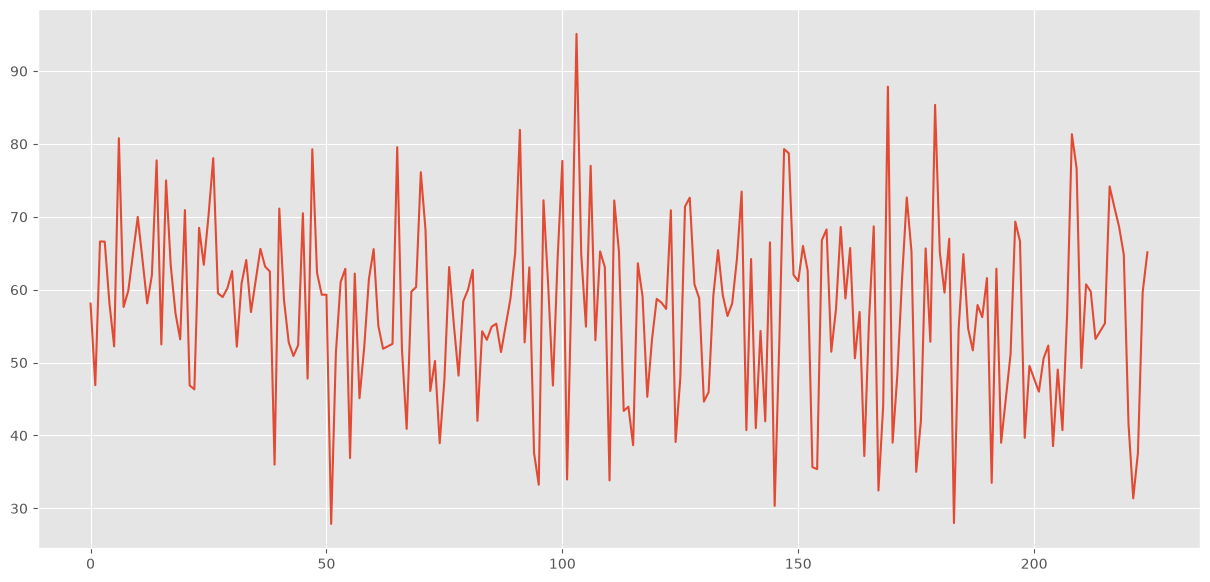

In [174]:
cleaned_employment_ratio['Total'].plot()

Text(0, 0.5, '')

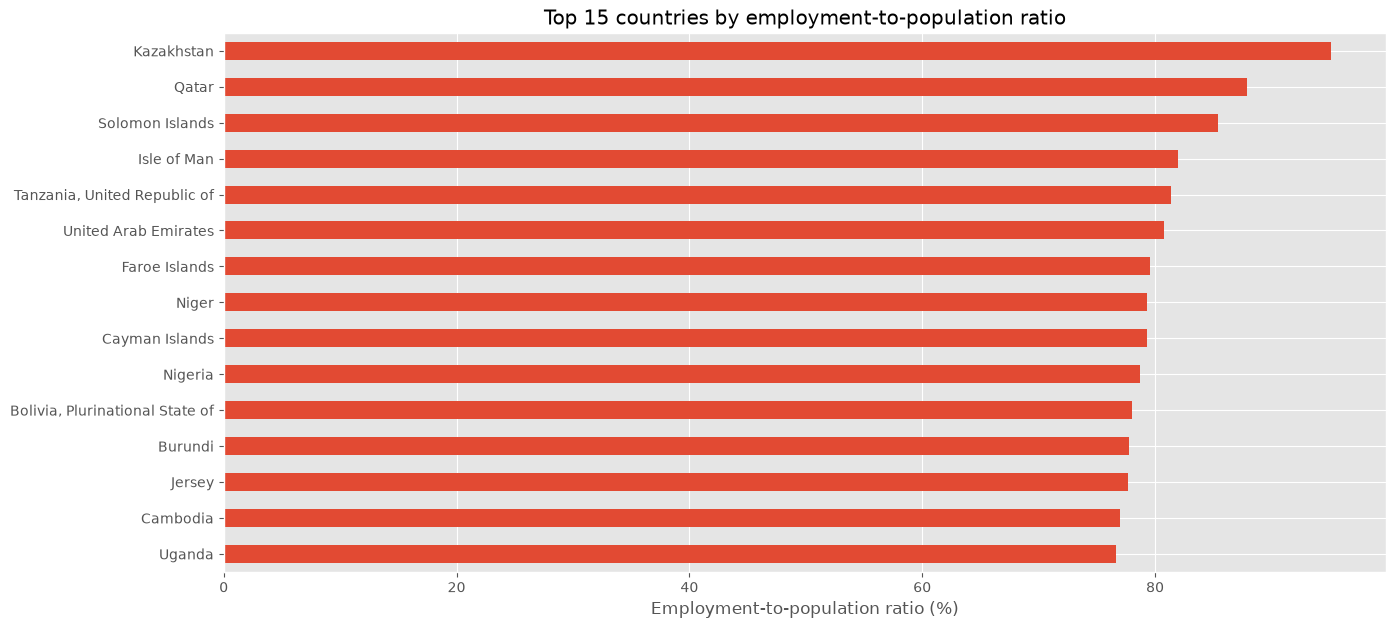

In [144]:
ax = (cleaned_employment_ratio
      .set_index('Area')['Total']
      .sort_values(ascending=False)
      .head(15)
      .plot(kind='barh', title='Top 15 countries by employment-to-population ratio'))

ax.invert_yaxis()   #  highest value at the top
ax.set_xlabel('Employment-to-population ratio (%)')
ax.set_ylabel('')

<Axes: ylabel='Frequency'>

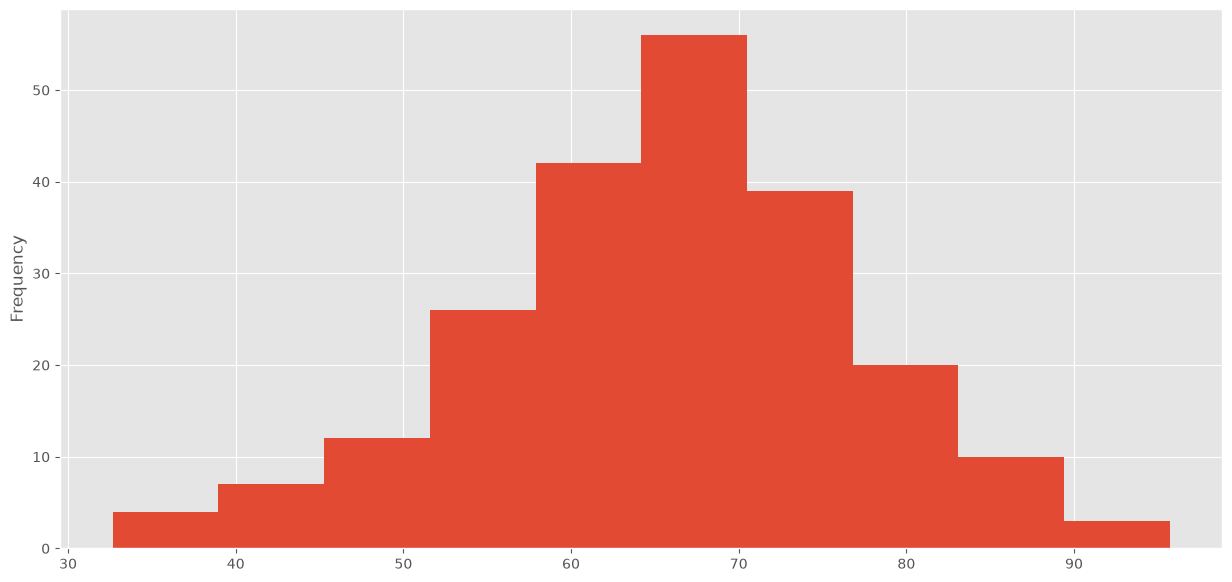

In [145]:
cleaned_employment_ratio['Male'].plot.hist()

<Axes: ylabel='Frequency'>

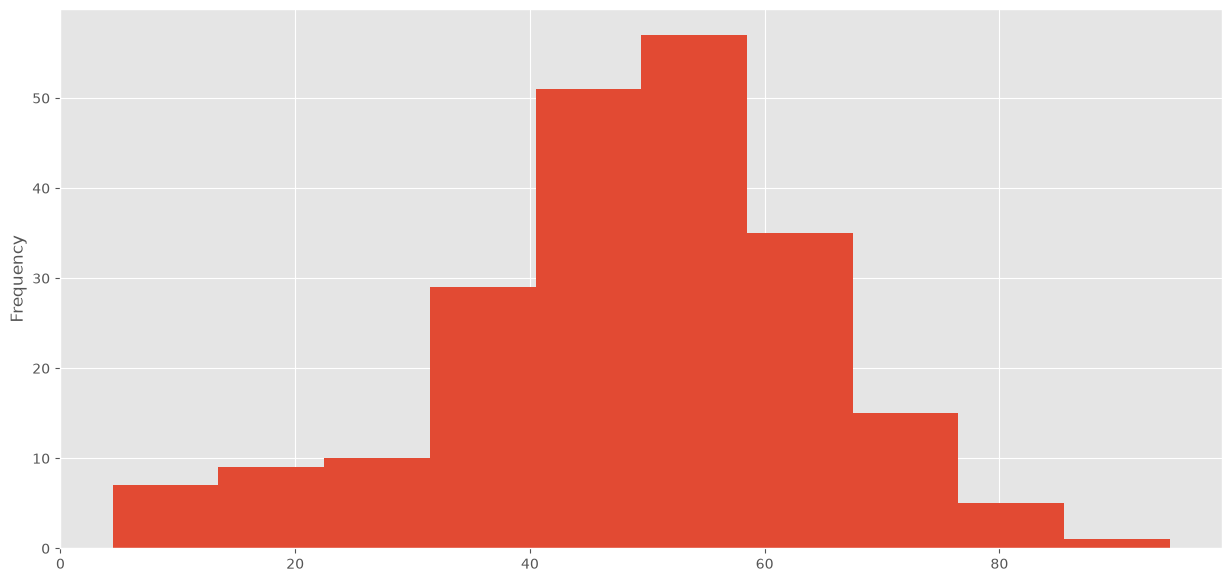

In [146]:
cleaned_employment_ratio['Female'].plot.hist()

In [147]:
cleaned_employment_ratio[['Total', 'Male', 'Female']].describe()

,Total,Male,Female
count,219.000000,219.000000,219.000000
mean,57.370479,65.898064,48.813169
std,12.294571,11.283434,15.541777
min,27.870000,32.667000,4.460000
25%,50.578000,59.462000,40.447500
50%,58.742000,65.970000,49.991000
75%,65.091000,72.698500,58.951000
max,95.100000,95.700000,94.500000


## Ranking

In [148]:
cleaned_employment_ratio.set_index('Area')['Total'].sort_values(ascending=False).head(15)

Area
Kazakhstan                         95.100
Qatar                              87.860
Solomon Islands                    85.363
Isle of Man                        81.935
Tanzania, United Republic of       81.342
United Arab Emirates               80.786
Faroe Islands                      79.556
Niger                              79.292
Cayman Islands                     79.277
Nigeria                            78.719
Bolivia, Plurinational State of    78.054
Burundi                            77.748
Jersey                             77.678
Cambodia                           76.999
Uganda                             76.648
Name: Total, dtype: float64

## Distribution difference

In [149]:
cleaned_employment_ratio['Gap'] = cleaned_employment_ratio['Male'] - cleaned_employment_ratio['Female']
cleaned_employment_ratio.set_index('Area')['Gap'].round(2).sort_values(ascending=False).head(15)

Area
Syrian Arab Republic         57.60
Yemen                        52.88
Pakistan                     51.22
Iran, Islamic Republic of    51.10
Iraq                         50.78
Afghanistan                  50.54
Saudi Arabia                 50.04
Oman                         49.26
Egypt                        47.10
Algeria                      46.50
Morocco                      46.00
Sudan                        45.80
Bahrain                      44.79
India                        41.06
Kuwait                       40.04
Name: Gap, dtype: float64

## Adding a 'Gap' column 

In [152]:
export = cleaned_employment_ratio.copy()
export['Gap'] = export['Gap'].map('{:.2f}'.format)
export.to_csv("cleaned_employment_ratio.csv", index=False)

## Mean, Mode and Median

In [151]:
columns = ['Total', 'Male', 'Female']

summary = pd.DataFrame({
    'Mean': cleaned_employment_ratio[columns].mean(),
    'Median': cleaned_employment_ratio[columns].median(),
    'Mode': cleaned_employment_ratio[columns].mode().iloc[0]
}).round(2)

print(summary)

         Mean  Median   Mode
Total   57.37   58.74  27.87
Male    65.90   65.97  32.67
Female  48.81   49.99   4.46


In [171]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.title("Employment to Population Ratio")
st.write("This app shows gender distribution in employment compared to the population.")

df = pd.read_csv("cleaned_employment_ratio.csv")

st.subheader("Top 15 countries by employment-to-population ratio")
st.bar_chart(df.nlargest(15, "Total"), x="Area", y="Total", horizontal=True, sort="-Total")

st.subheader("Male and female ratios")
st.scatter_chart(df, x="Male", y="Female")

st.subheader("Largest gender gaps")
st.dataframe(df.sort_values("Gap", ascending=False).head(15), hide_index=True)

Overwriting app.py


In [172]:
import subprocess

# Launch Streamlit process on port 8501
streamlit_process = subprocess.Popen(["streamlit", "run", "app.py"])
print("Streamlit app is running in the background!")


Streamlit app is running in the background!
